In [5]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime, timedelta
from statsmodels.tsa.stattools import adfuller, kpss
import matplotlib.dates as mdates

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pmdarima
from pmdarima import ARIMA
from pmdarima import auto_arima


In [6]:
# Loading data

data_full = pd.read_csv("merged_data.csv")
data_full.set_index('time',inplace=True)
data_full.index = pd.to_datetime(data_full.index)
data_full.index = data_full.index.tz_localize(None)
data_full.head(3)

,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,ESP discharge pressure,...,extValues_ESP discharge temperature sensor,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature,Failure distance
time,,,,,,,,,,,,,,,,,,,,,
2011-04-09 21:00:00,57.00,58.10,58.01,39.67,13.64,97.72,220.50,0.1,81.22,318.22,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 03:00:00
2011-04-09 22:00:00,66.05,68.63,68.00,39.75,13.64,83.10,204.45,0.1,81.22,287.55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 02:00:00
2011-04-09 23:00:00,72.00,74.00,73.00,39.80,13.64,58.77,197.27,0.1,81.22,256.04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 01:00:00


In [7]:
data_full.drop(data_full[data_full['VSD power frequency'] < 7].index,inplace=True)
data_full.head(3)

,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,ESP discharge pressure,...,extValues_ESP discharge temperature sensor,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature,Failure distance
time,,,,,,,,,,,,,,,,,,,,,
2011-04-09 21:00:00,57.00,58.10,58.01,39.67,13.64,97.72,220.50,0.1,81.22,318.22,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 03:00:00
2011-04-09 22:00:00,66.05,68.63,68.00,39.75,13.64,83.10,204.45,0.1,81.22,287.55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 02:00:00
2011-04-09 23:00:00,72.00,74.00,73.00,39.80,13.64,58.77,197.27,0.1,81.22,256.04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 01:00:00


In [8]:
data_full.drop(data_full[pd.isna(data_full['VSD power frequency'])].index,inplace=True)
data_full.head(3)

,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,ESP discharge pressure,...,extValues_ESP discharge temperature sensor,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature,Failure distance
time,,,,,,,,,,,,,,,,,,,,,
2011-04-09 21:00:00,57.00,58.10,58.01,39.67,13.64,97.72,220.50,0.1,81.22,318.22,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 03:00:00
2011-04-09 22:00:00,66.05,68.63,68.00,39.75,13.64,83.10,204.45,0.1,81.22,287.55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 02:00:00
2011-04-09 23:00:00,72.00,74.00,73.00,39.80,13.64,58.77,197.27,0.1,81.22,256.04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 01:00:00


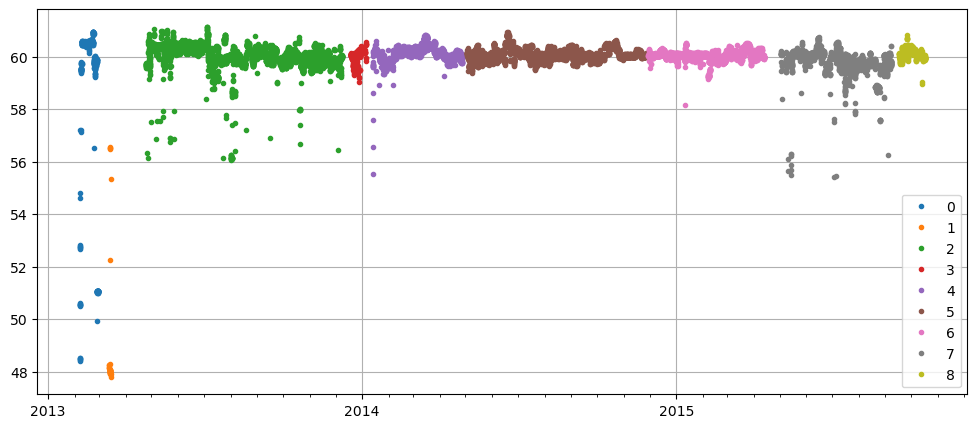

In [10]:
# Dividing data by month

# Getting info
vsd_name = 'VSD power frequency'
well_ids = np.unique(data_full['Well Run'])
#well = np.random.choice(well_ids,1,replace=False)
well = ['A-24 1']
vsd_data = data_full[data_full['Well Run'] ==well[0]][vsd_name]

# Getting data time range
year1 = np.min(vsd_data.index.year)
month1 = np.min(vsd_data.index[vsd_data.index.year==year1].month)

year2 = np.max(vsd_data.index.year)
month2 = np.max(vsd_data.index[vsd_data.index.year==year2].month)+1
if month2 == 13:
    month2 = 1
    year2 += 1


# Creating date array
first = datetime(year1, month1, 1, 0, 0, 0)
last = datetime(year2, month2, 1, 0, 0, 0)
delta = timedelta(hours = 1)
dates = pd.date_range(start=first, end=last, freq='H')
days = pd.DataFrame(index = dates,
                   data = np.zeros(dates.size))
days.loc[vsd_data.index,0] = 1


# Dividing by groups

max_date_difference = 1

border_ind = vsd_data.index[vsd_data.index.to_series().diff().dt.days>max_date_difference]

data_blocks = [None]*(border_ind.size+1)
num_blocks = 0

if border_ind.size == 0:
    block = vsd_data
    data_blocks[0] = block
    num_blocks = 1

else:
    for i in range(border_ind.size):
        
        if i>0:
            block =  vsd_data.loc[np.logical_and(vsd_data.index<border_ind[i],vsd_data.index>=border_ind[i-1])]
        else:
            block =  vsd_data.loc[vsd_data.index<border_ind[i]]
    
        if block.size > 0: 
            if (block.index[-1]-block.index[0]).days > max_date_difference:
                data_blocks[num_blocks] = block
                num_blocks += 1

    block =  vsd_data.loc[vsd_data.index>=border_ind[i]]
    if block.size > 0:
        if (block.index[-1]-block.index[0]).days > max_date_difference:
            data_blocks[num_blocks] = block
            num_blocks += 1


plt.figure()
for j in range(num_blocks):
    block = data_blocks[j]
    mn = block.mean()
    md = block.median()
    st = block.std()
    
    qt = (block-md).abs().quantile(q=0.90)


    block.drop(block[np.abs(block-mn)>1*st].index,inplace=True)
    #c = b.drop(b[np.abs(b-md)>qt].index,inplace=False)
    
    plt.figure(1)
    plt.plot(block,'.',label=j)

    #plt.figure(2)
    #plt.plot(c,'.')


plt.legend()
for j in [1]:
    plt.figure(j)
    plt.grid(True)
    plt.gcf().set_size_inches(12,5)
    plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())

#from statsmodels.tsa.deterministic import TimeTrend
#trend_gen = TimeTrend(True, 1)
#trend_gen.in_sample(vsd.index)
#trend_gen.in_sample(vsd)

In [6]:
# Block to be trained
b = 6
block = data_blocks[b]
ind = block.index

# Getting exogenous variables
grau_exog = 8
exog_vars = ['VSD power frequency','ESP motor Current - phase A','ESP motor Current - phase B','ESP motor Current - phase C','Water Cut @ 20degC/1 atm','ESP intake Pressure','ESP Motor Voltage'\
       ]

#'ESP motor Current - phase A'
#'ESP motor Current - phase B'
#'ESP motor Current - phase C'
#'VSD power frequency'
#'ESP intake Pressure'
#'Water Cut @ 20degC/1 atm'
#'ESP Motor Voltage'


exog = data_full[data_full['Well Run'] ==well[0]].loc[ind,exog_vars].shift(range(grau_exog),fill_value=0)
exog.interpolate(method='linear')


# Training data
data_name = 'ESP discharge pressure'
y = data_full[data_full['Well Run'] ==well[0]].loc[ind,data_name]
#data_full['Well head pressure']
exog.columns

Index(['VSD power frequency_0', 'ESP motor Current - phase A_0',
       'ESP motor Current - phase B_0', 'ESP motor Current - phase C_0',
       'Water Cut @ 20degC/1 atm_0', 'ESP intake Pressure_0',
       'ESP Motor Voltage_0', 'VSD power frequency_1',
       'ESP motor Current - phase A_1', 'ESP motor Current - phase B_1',
       'ESP motor Current - phase C_1', 'Water Cut @ 20degC/1 atm_1',
       'ESP intake Pressure_1', 'ESP Motor Voltage_1', 'VSD power frequency_2',
       'ESP motor Current - phase A_2', 'ESP motor Current - phase B_2',
       'ESP motor Current - phase C_2', 'Water Cut @ 20degC/1 atm_2',
       'ESP intake Pressure_2', 'ESP Motor Voltage_2', 'VSD power frequency_3',
       'ESP motor Current - phase A_3', 'ESP motor Current - phase B_3',
       'ESP motor Current - phase C_3', 'Water Cut @ 20degC/1 atm_3',
       'ESP intake Pressure_3', 'ESP Motor Voltage_3', 'VSD power frequency_4',
       'ESP motor Current - phase A_4', 'ESP motor Current - phase B_4',
   

In [7]:
test_size = 300
# Getting data
ord = (12,1,12)

mod = ARIMA(order=ord,trend='c',with_intercept=True,out_of_sample_size=test_size)
res = mod.fit(y,X=exog,disp=0)
#res = mod.fit(y,disp=0)

res.summary()

/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/epic-heitor/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2674
Model:             SARIMAX(12, 1, 12)   Log Likelihood               -2265.059
Date:                Mon, 30 Sep 2024   AIC                           4694.118
Time:                        14:44:53   BIC                           5177.177
Sample:                             0   HQIC                          4868.896
                               - 2674                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0099      0.053     -0.187      0.852      -0.114       0.094
x1             1.0077      0.141      7.128      0.000       0.731       1.285
x2            -0.1334      0.046     -2.895      0.004      -0.224      -0.043
x3            -0.1318      0.043     -3.036      0.002      -0.217      -0.047
x4            -0.0515      0.049     -1.059      0.290      -0.147       0.044
x5            -3.8972      1.053     -3.701      0.000      -5.961      -1.833
x6             1.2296      0.011    110.512      0.000       1.208       1.251
x7             0.0277      0.002     12.969      0.000       0.024       0.032
x8             0.0325      0.187      0.174      0.862      -0.334       0.399
x9             0.0584      0.052      1.134      0.257      -0.043       0.159
x10           -0.1280      0.053     -2.417      0.016      -0.232      -0.024
x11           -0.1267      0.060     -2.119      0.034      -0.244      -0.010
x12           -0.3788      0.584     -0.648      0.517      -1.524       0.766
x13           -0.2373      0.011    -22.358      0.000      -0.258      -0.217
x14            0.0100      0.002      4.220      0.000       0.005       0.015
x15           -0.5070      0.193     -2.624      0.009      -0.886      -0.128
x16            0.0792      0.052      1.536      0.125      -0.022       0.180
x17           -0.0131      0.059     -0.222      0.824      -0.129       0.103
x18           -0.0948      0.063     -1.505      0.132      -0.218       0.029
x19            2.8433      0.579      4.911      0.000       1.709       3.978
x20           -0.3307      0.017    -19.126      0.000      -0.365      -0.297
x21            0.0030      0.003      1.151      0.250      -0.002       0.008
x22           -0.3780      0.190     -1.986      0.047      -0.751      -0.005
x23            0.0954      0.053      1.811      0.070      -0.008       0.199
x24           -0.0041      0.062     -0.067      0.946      -0.125       0.117
x25           -0.0889      0.063     -1.413      0.158      -0.212       0.034
x26            1.3104      0.644      2.036      0.042       0.049       2.572
x27           -0.2079      0.022     -9.648      0.000      -0.250      -0.166
x28            0.0036      0.003      1.272      0.204      -0.002       0.009
x29           -0.5352      0.183     -2.926      0.003      -0.894      -0.177
x30            0.0553      0.059      0.944      0.345      -0.060       0.170
x31            0.0740      0.058      1.279      0.201      -0.039       0.187
x32           -0.1099      0.063     -1.747      0.081      -0.233       0.013
x33            1.5698      0.649      2.419      0.016       0.298       2.842
x34           -0.1424      0.025     -5.722      0.000      -0.191      -0.094
x35            0.0029      0.003      1.001      0.317      -0.003       0.008
x36           -0.1197      0.209     -0.572      0.567      -0.529       0.290
x37            0.0384      0.058      0.656      0.512      -0.076       0.153
x3

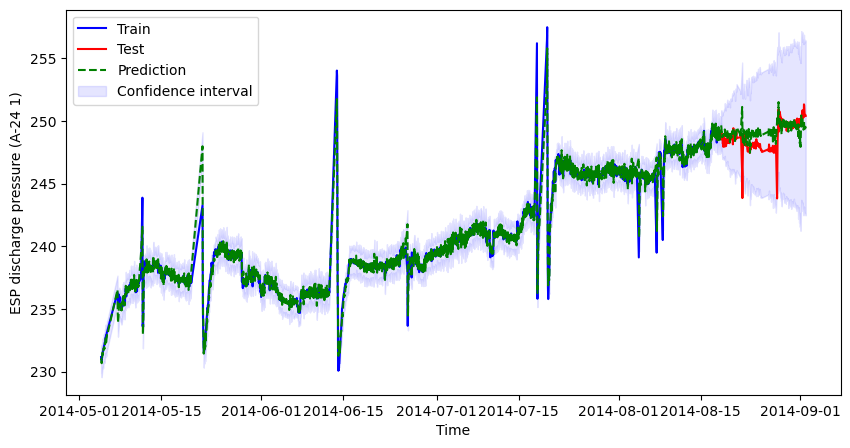

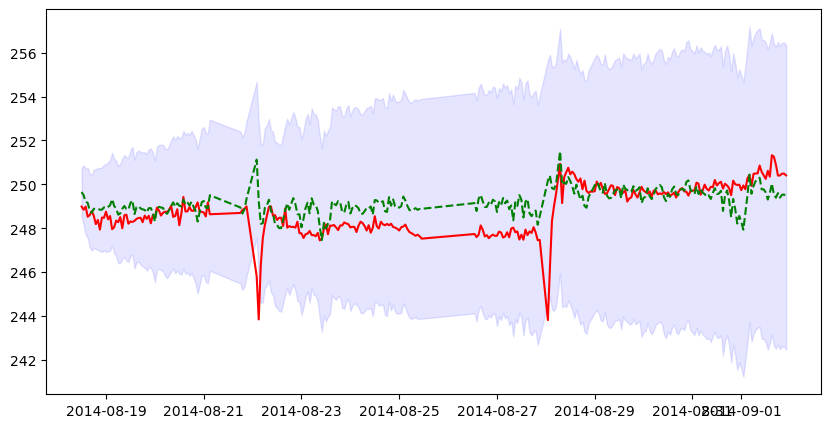

In [82]:
fitted, confint = res.predict(n_periods=test_size,X=exog[-test_size:], return_conf_int=True)
fitted_vals,confint_sample = res.predict_in_sample(return_conf_int=True,X=exog)


n = 40
plt.plot(y[n:-test_size],'b-')
plt.plot(y[-test_size:],'r-')

plt.plot(ind[-test_size:],fitted,'g--')


plt.fill_between(ind[-test_size:],confint[-test_size:,0],confint[-test_size:,1],color='b',alpha=0.1)
plt.plot(ind[n:-test_size],fitted_vals[n:-test_size],'g--')
plt.fill_between(ind[n:-test_size],confint_sample[n:-test_size,0],confint_sample[n:-test_size,1],color='b',alpha=0.1)

plt.gcf().set_size_inches(10,5)

plt.xlabel("Time")
plt.ylabel(f'{data_name} ({well[0]})')

plt.legend(['Train', 'Test', 'Prediction','Confidence interval'])


plt.figure()
plt.plot(y[-test_size:],'r-')
plt.plot(ind[-test_size:],fitted,'g--')
plt.fill_between(ind[-test_size:],confint[-test_size:,0],confint[-test_size:,1],color='b',alpha=0.1)
plt.gcf().set_size_inches(10,5)

Text(0.5, 1.0, 'Inverse MA roots')

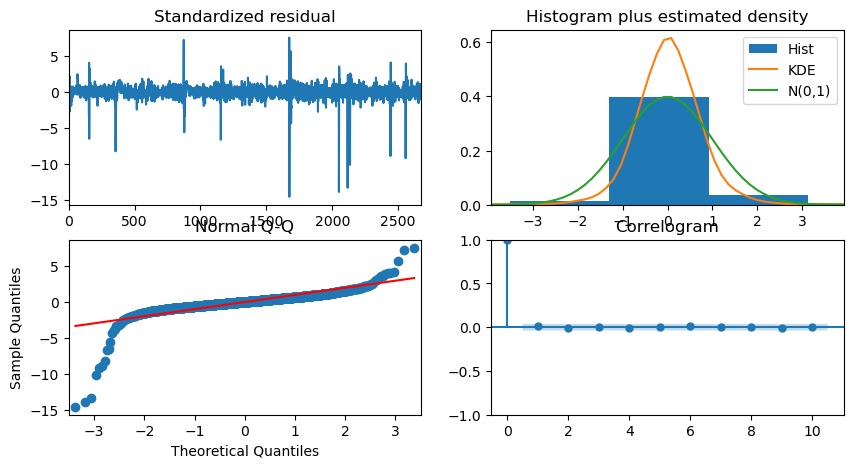

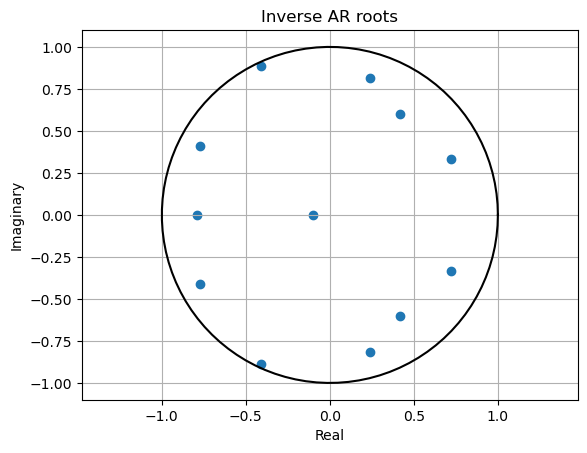

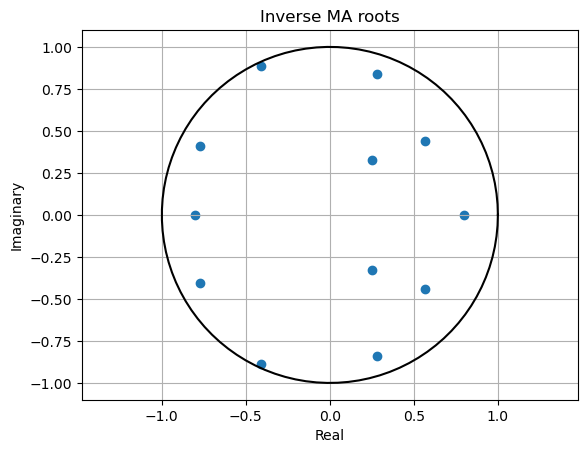

In [8]:
res.plot_diagnostics();
plt.gcf().set_size_inches(10,5)
plt.figure()

ar_roots = 1/res.arroots()
plt.scatter(ar_roots.real,ar_roots.imag)
theta = np.linspace(0,2*np.pi,100)
plt.plot(np.cos(theta),np.sin(theta),'k-')

ax  = plt.gca();
ax.axis('equal');
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.grid(True)
ax.set_title('Inverse AR roots')

plt.figure()

ma_roots = 1/res.maroots()
plt.scatter(ma_roots.real,ma_roots.imag)
theta = np.linspace(0,2*np.pi,100)
plt.plot(np.cos(theta),np.sin(theta),'k-')



ax  = plt.gca();
ax.axis('equal');

plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.grid(True)
ax.set_title('Inverse MA roots')

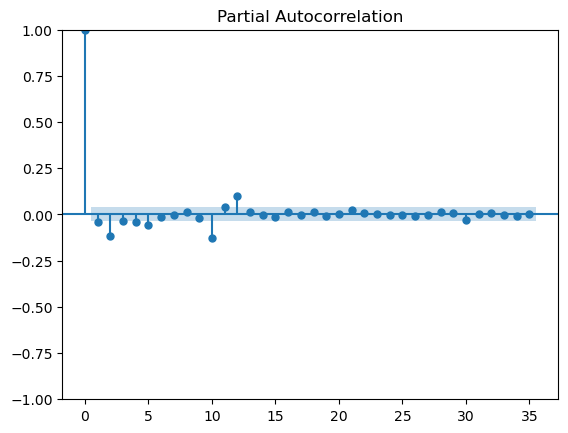

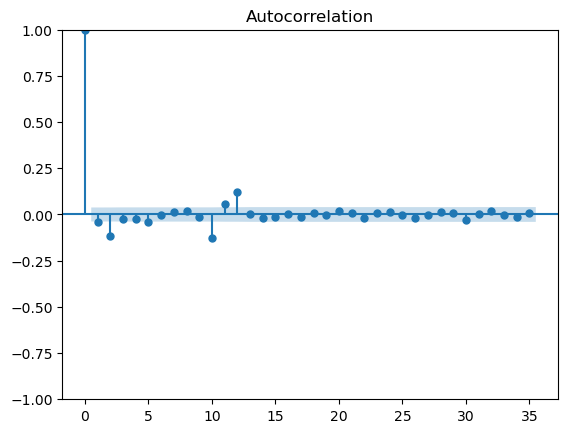

In [48]:
plot_pacf(np.diff(y));
plot_acf(np.diff(y));

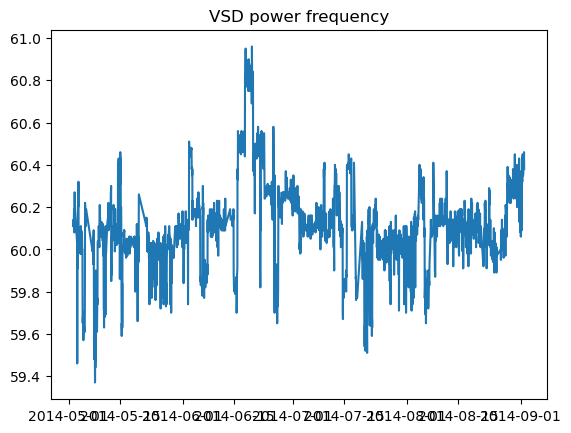

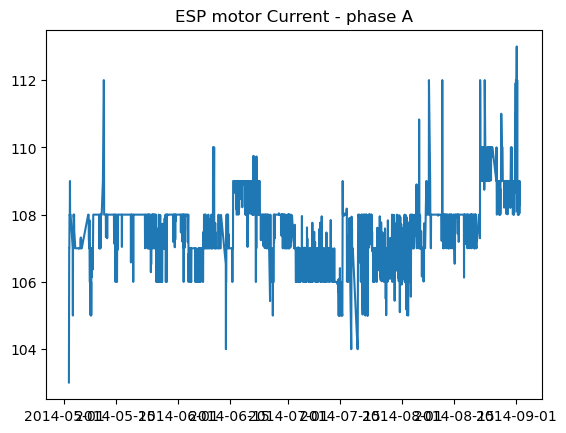

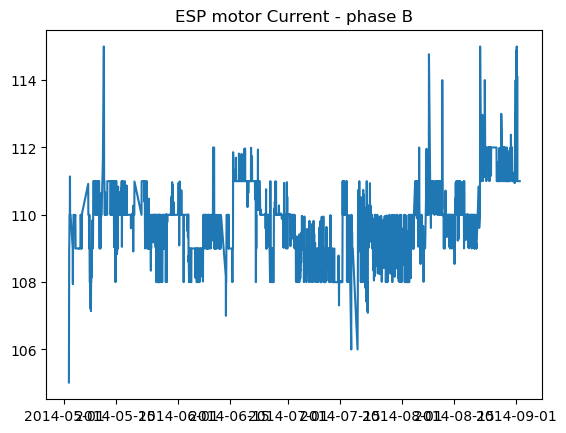

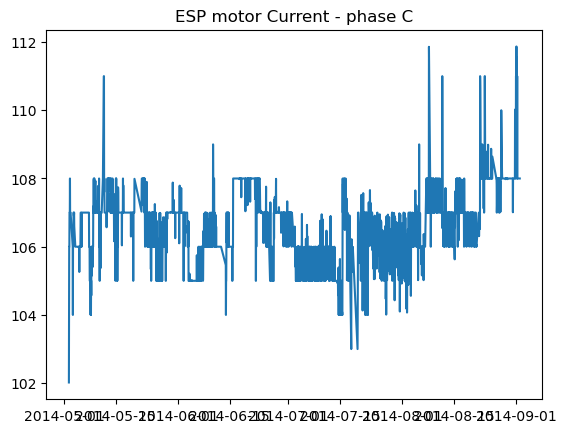

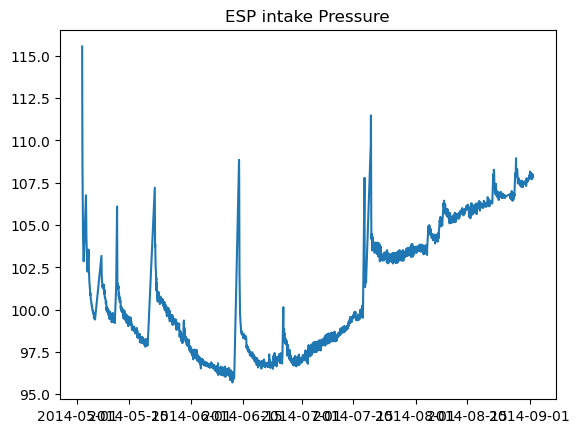

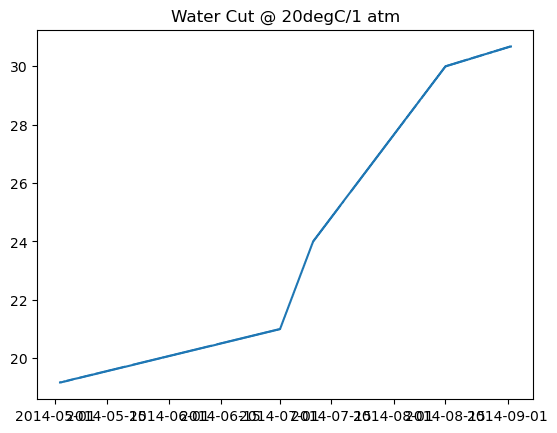

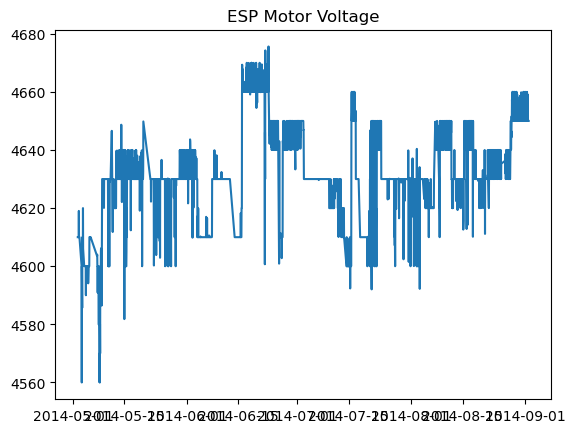

In [13]:

ex = ['VSD power frequency',\
'ESP motor Current - phase A',\
'ESP motor Current - phase B',\
'ESP motor Current - phase C',\
'ESP intake Pressure',\
'Water Cut @ 20degC/1 atm',\
'ESP Motor Voltage']

for d in ex:

    plt.figure()
    plt.plot(data_full[data_full['Well Run'] ==well[0]].loc[ind,d])
    plt.title(d)


#'ESP motor Current - phase A'
#'ESP motor Current - phase B'
#'ESP motor Current - phase C'
#'VSD power frequency'
#'ESP intake Pressure'
#'Water Cut @ 20degC/1 atm'
#'ESP Motor Voltage'